In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/processed/forecast_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/forecast_dataset.csv'

In [3]:
df = pd.read_csv("../data/processed/forecast_dataset.csv")

In [4]:
df.head()

,ds,y
0,2011-01-29,0
1,2011-01-30,0
2,2011-01-31,0
3,2011-02-01,0
4,2011-02-02,0


In [5]:
df["ds"] = pd.to_datetime(df["ds"])

In [6]:
model = Prophet()

In [7]:
model.fit(df)

12:47:57 - cmdstanpy - INFO - Chain [1] start processing
12:47:58 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(periods=30)

In [9]:
forecast = model.predict(future)

In [10]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1938,2016-05-20,0.620155,-0.137519,1.387598
1939,2016-05-21,0.771913,-0.007726,1.545402
1940,2016-05-22,0.654344,-0.099493,1.452231
1941,2016-05-23,0.609859,-0.124833,1.371062
1942,2016-05-24,0.676912,-0.090938,1.443632


In [11]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1938,2016-05-20,0.620155,-0.137519,1.387598
1939,2016-05-21,0.771913,-0.007726,1.545402
1940,2016-05-22,0.654344,-0.099493,1.452231
1941,2016-05-23,0.609859,-0.124833,1.371062
1942,2016-05-24,0.676912,-0.090938,1.443632


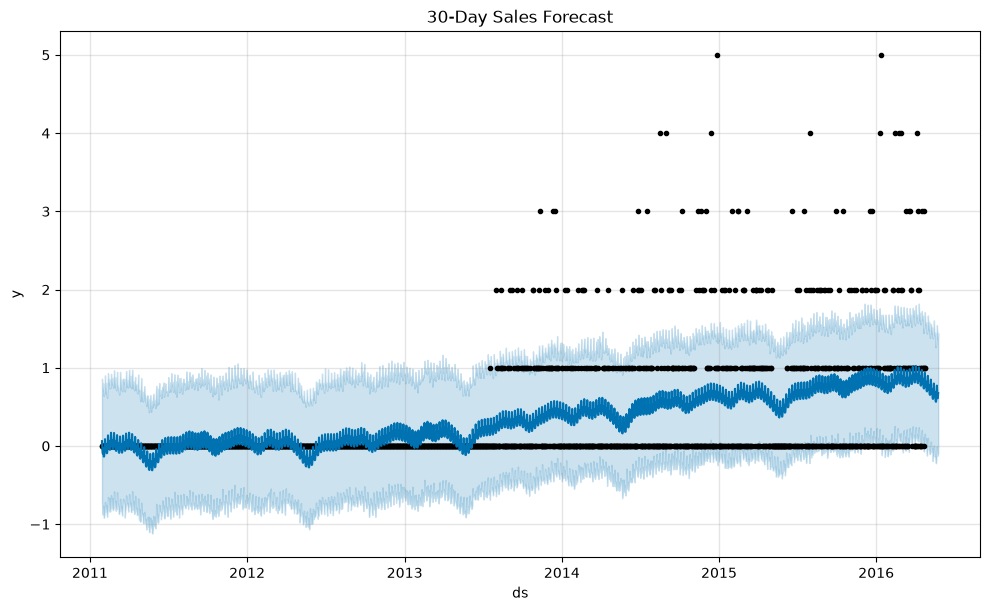

In [12]:
fig = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

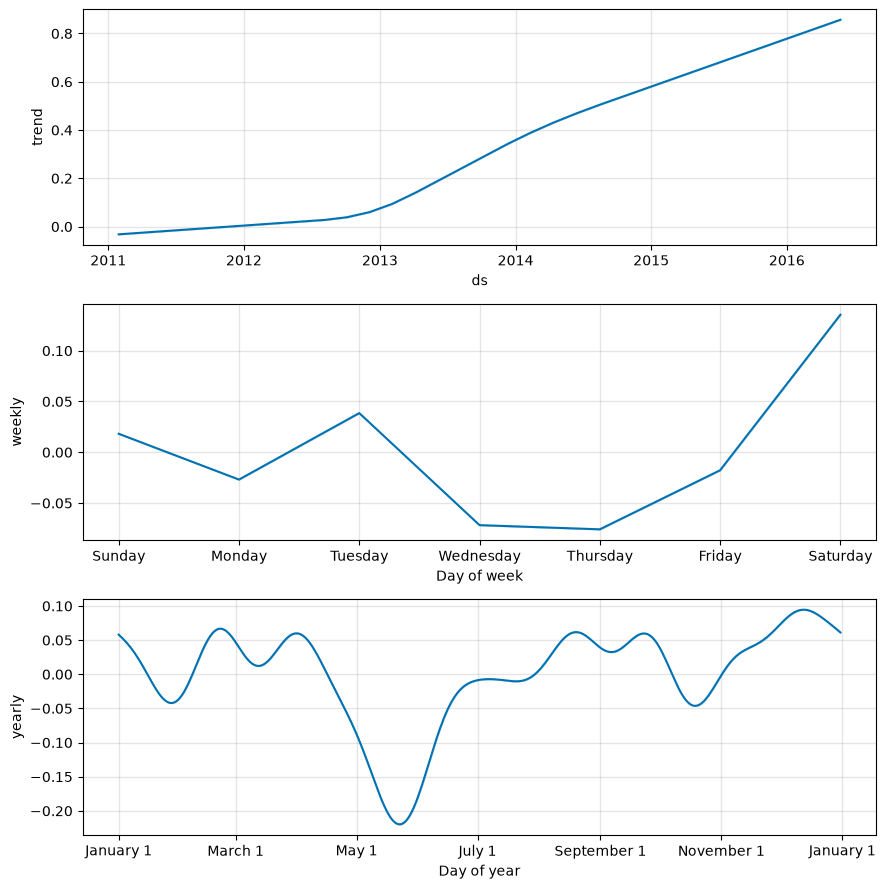

In [13]:
fig2 = model.plot_components(forecast)
plt.show()

In [14]:
forecast.to_csv(
    "../data/processed/prophet_forecast.csv",
    index=False
)